In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.preprocessing import load_and_clean, TARGET

os.makedirs("reports", exist_ok=True)
sns.set_style("whitegrid")

df = load_and_clean()
print(df.shape)

(142017, 24)


HeavyRainTomorrow
0    141554
1       463
Name: count, dtype: int64
Heavy rain %: 0.33


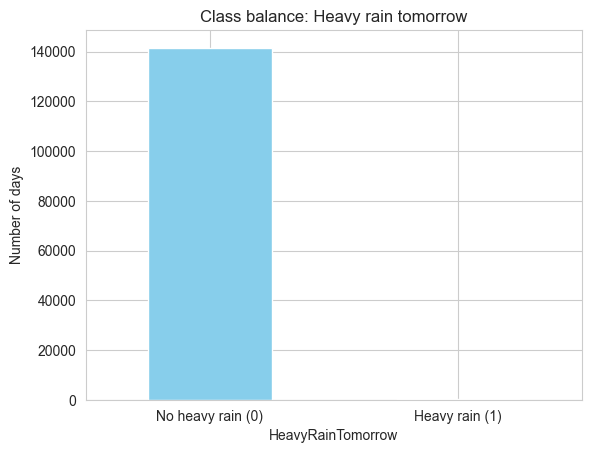

In [2]:
counts = df[TARGET].value_counts()
print(counts)
print("Heavy rain %:", round(counts[1] / len(df) * 100, 2))

counts.plot(kind="bar", color=["skyblue", "crimson"])
plt.xticks([0, 1], ["No heavy rain (0)", "Heavy rain (1)"], rotation=0)
plt.title("Class balance: Heavy rain tomorrow")
plt.ylabel("Number of days")
plt.savefig("reports/1_class_balance.png", bbox_inches="tight")
plt.show()

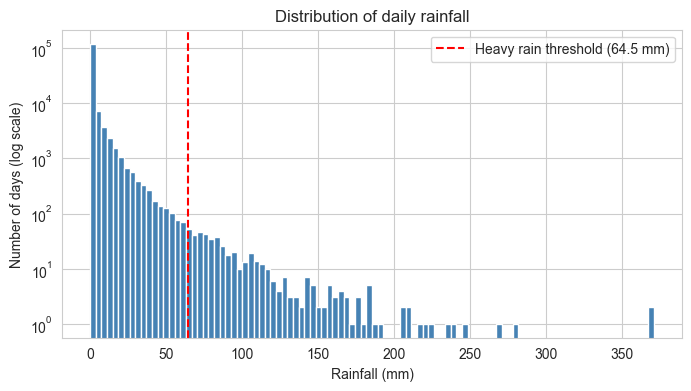

In [3]:
plt.figure(figsize=(8, 4))
plt.hist(df["Rainfall"].dropna(), bins=100, color="steelblue")
plt.yscale("log")
plt.axvline(64.5, color="red", linestyle="--", label="Heavy rain threshold (64.5 mm)")
plt.title("Distribution of daily rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Number of days (log scale)")
plt.legend()
plt.savefig("reports/2_rainfall_distribution.png", bbox_inches="tight")
plt.show()

Location
Cairns           57
CoffsHarbour     45
Townsville       43
Darwin           40
GoldCoast        34
Brisbane         31
Wollongong       26
Sydney           19
NorfolkIsland    15
NorahHead        14
SydneyAirport    14
Williamtown      12
Newcastle        12
Katherine        12
Tuggeranong      11
Name: HeavyRainTomorrow, dtype: int64


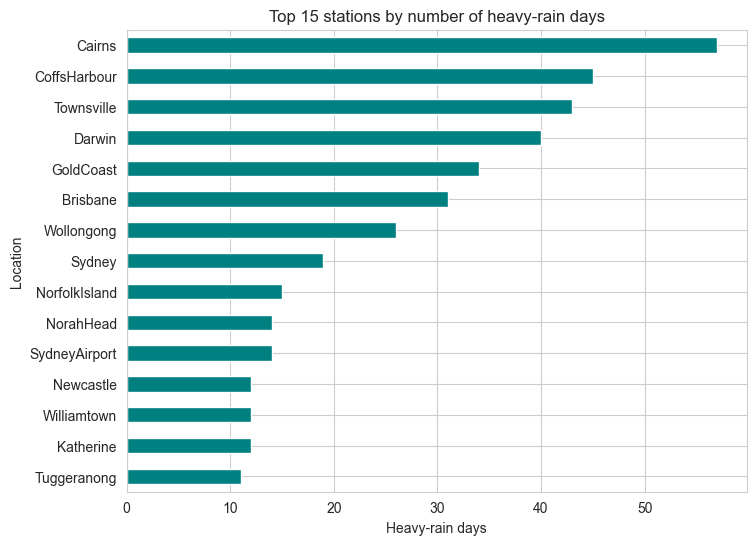

In [4]:
by_station = df.groupby("Location")[TARGET].sum().sort_values(ascending=False).head(15)
print(by_station)

by_station.sort_values().plot(kind="barh", figsize=(8, 6), color="teal")
plt.title("Top 15 stations by number of heavy-rain days")
plt.xlabel("Heavy-rain days")
plt.savefig("reports/3_heavy_rain_by_station.png", bbox_inches="tight")
plt.show()

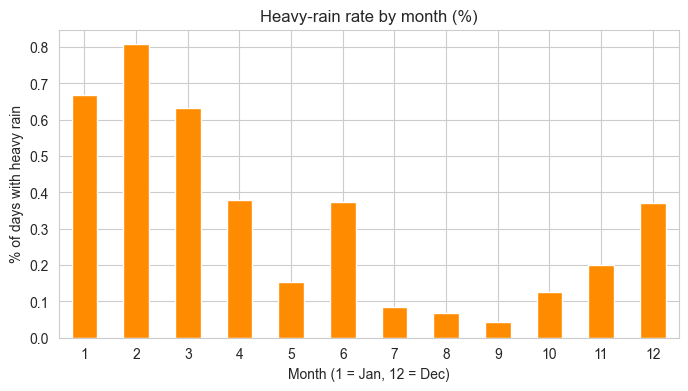

In [5]:
by_month = df.groupby("Month")[TARGET].mean() * 100

by_month.plot(kind="bar", color="darkorange", figsize=(8, 4))
plt.title("Heavy-rain rate by month (%)")
plt.xlabel("Month (1 = Jan, 12 = Dec)")
plt.ylabel("% of days with heavy rain")
plt.xticks(rotation=0)
plt.savefig("reports/4_heavy_rain_by_month.png", bbox_inches="tight")
plt.show()

Sunshine        -0.093904
Pressure3pm     -0.045871
Pressure9am     -0.044091
Month           -0.030758
Evaporation     -0.000135
Temp3pm          0.004350
MaxTemp          0.008870
WindSpeed3pm     0.024138
WindSpeed9am     0.031437
Temp9am          0.040121
WindGustSpeed    0.050734
Humidity9am      0.052983
Cloud9am         0.060112
MinTemp          0.062905
Cloud3pm         0.071235
Humidity3pm      0.094105
Rainfall         0.177599
Name: HeavyRainTomorrow, dtype: float64


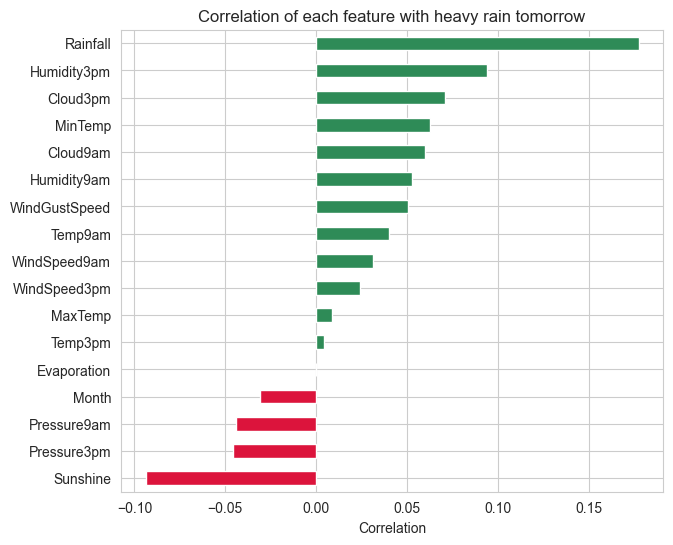

In [6]:
num_df = df.select_dtypes(include="number")
corr = num_df.corr()[TARGET].drop(TARGET).sort_values()
print(corr)

corr.plot(kind="barh", figsize=(7, 6), color=["crimson" if v < 0 else "seagreen" for v in corr])
plt.title("Correlation of each feature with heavy rain tomorrow")
plt.xlabel("Correlation")
plt.savefig("reports/5_correlation_with_target.png", bbox_inches="tight")
plt.show()

C:\Users\kanis\AppData\Local\Temp\ipykernel_15640\3130209700.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, ax=ax, palette=["skyblue", "crimson"])
C:\Users\kanis\AppData\Local\Temp\ipykernel_15640\3130209700.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, ax=ax, palette=["skyblue", "crimson"])
C:\Users\kanis\AppData\Local\Temp\ipykernel_15640\3130209700.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, ax=ax, palette=["skyblue", "crimson"])


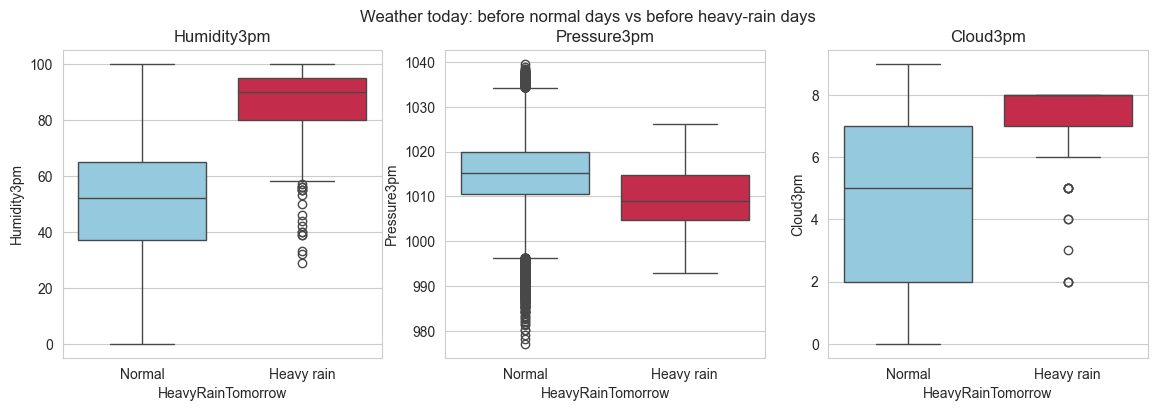

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["Humidity3pm", "Pressure3pm", "Cloud3pm"]):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax, palette=["skyblue", "crimson"])
    ax.set_xticks([0, 1], ["Normal", "Heavy rain"])
    ax.set_title(col)
plt.suptitle("Weather today: before normal days vs before heavy-rain days")
plt.savefig("reports/6_boxplots_key_features.png", bbox_inches="tight")
plt.show()

In [8]:
df["TempRange"]      = df["MaxTemp"] - df["MinTemp"]
df["HumidityChange"] = df["Humidity3pm"] - df["Humidity9am"]
df["PressureChange"] = df["Pressure3pm"] - df["Pressure9am"]

df["Rain3dSum"] = (df.groupby("Location")["Rainfall"]
                     .transform(lambda s: s.rolling(3, min_periods=1).sum()))

df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

new_cols = ["TempRange", "HumidityChange", "PressureChange", "Rain3dSum", "Month_sin", "Month_cos"]
df[["Location", "Date"] + new_cols].head()

,Location,Date,TempRange,HumidityChange,PressureChange,Rain3dSum,Month_sin,Month_cos
0,Adelaide,2008-07-01,6.9,-25.0,0.3,5.0,-0.5,-0.866025
1,Adelaide,2008-07-02,3.1,-23.0,0.2,5.8,-0.5,-0.866025
2,Adelaide,2008-07-03,8.9,-25.0,-1.3,5.8,-0.5,-0.866025
3,Adelaide,2008-07-04,10.6,-25.0,-3.1,0.8,-0.5,-0.866025
5,Adelaide,2008-07-06,4.4,0.0,-3.3,0.0,-0.5,-0.866025


In [9]:
compare = df.groupby(TARGET)[new_cols].mean().T
compare.columns = ["Normal day (0)", "Before heavy rain (1)"]
print(compare.round(2))

                Normal day (0)  Before heavy rain (1)
TempRange                11.06                   5.09
HumidityChange          -17.42                  -0.73
PressureChange           -2.40                  -2.57
Rain3dSum                 6.84                  52.65
Month_sin                 0.01                   0.44
Month_cos                -0.02                   0.19


TempRange        -0.069
PressureChange   -0.005
Month_cos         0.017
Month_sin         0.035
HumidityChange    0.058
Rain3dSum         0.146
Name: HeavyRainTomorrow, dtype: float64


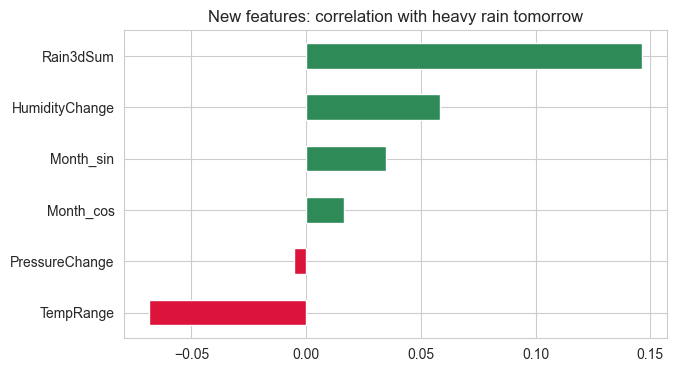

In [10]:
corr_new = df[new_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
print(corr_new.round(3))

corr_new.plot(kind="barh", color=["crimson" if v < 0 else "seagreen" for v in corr_new], figsize=(7, 4))
plt.title("New features: correlation with heavy rain tomorrow")
plt.savefig("reports/7_new_feature_correlation.png", bbox_inches="tight")
plt.show()

In [11]:
all_num = df.select_dtypes(include="number").drop(columns=[TARGET])
ranking = all_num.corrwith(df[TARGET]).abs().sort_values(ascending=False)
print(ranking.round(3))

Rainfall          0.178
Rain3dSum         0.146
Humidity3pm       0.094
Sunshine          0.094
Cloud3pm          0.071
TempRange         0.069
MinTemp           0.063
Cloud9am          0.060
HumidityChange    0.058
Humidity9am       0.053
WindGustSpeed     0.051
Pressure3pm       0.046
Pressure9am       0.044
Temp9am           0.040
Month_sin         0.035
WindSpeed9am      0.031
Month             0.031
WindSpeed3pm      0.024
Month_cos         0.017
MaxTemp           0.009
PressureChange    0.005
Temp3pm           0.004
Evaporation       0.000
dtype: float64


In [1]:
from src.preprocessing import load_and_clean, TARGET
from src.features import add_features, FEATURE_COLS

df3 = add_features(load_and_clean())
print(df3.shape)
print("Number of numeric features for the model:", len(FEATURE_COLS))

(142017, 30)
Number of numeric features for the model: 23
